# Transformers: Attention Is All You Need

**Pregunta:** Como funciona la arquitectura Transformer comparada con LSTM? Por que reemplazo a las LSTM en casi todos los campos?

---

## 1. El Problema Fundamental de las LSTM

Las LSTM procesan secuencias **paso a paso**:

```
x_1 → h_1 → x_2 → h_2 → x_3 → h_3 → ... → x_100 → h_100
```

Esto tiene dos problemas criticos:

**Problema 1: No se puede paralelizar.** Para calcular $h_{50}$, NECESITAS $h_{49}$, que necesita $h_{48}$, etc. Es inherentemente secuencial. Con una GPU de 4000 cores, solo usas 1.

**Problema 2: Distancia.** Para que la informacion del paso 1 llegue al paso 100, tiene que pasar por 99 operaciones de puerta. Aunque la LSTM es mejor que la RNN simple, la informacion se degrada con la distancia.

## 2. La Idea del Transformer (Vaswani et al., 2017)

"Attention Is All You Need" — literalmente. Eliminaron las recurrencias (loops) y las reemplazaron con un mecanismo llamado **Self-Attention** que permite a cada posicion "mirar" directamente a todas las demas.

```
LSTM:        x_1 → x_2 → x_3 → ... → x_100  (secuencial, 100 pasos)
Transformer: x_1, x_2, x_3, ..., x_100       (todos a la vez, 1 paso)
```

Cada posicion puede atender a cualquier otra posicion en **un solo paso**. No hay distancia.

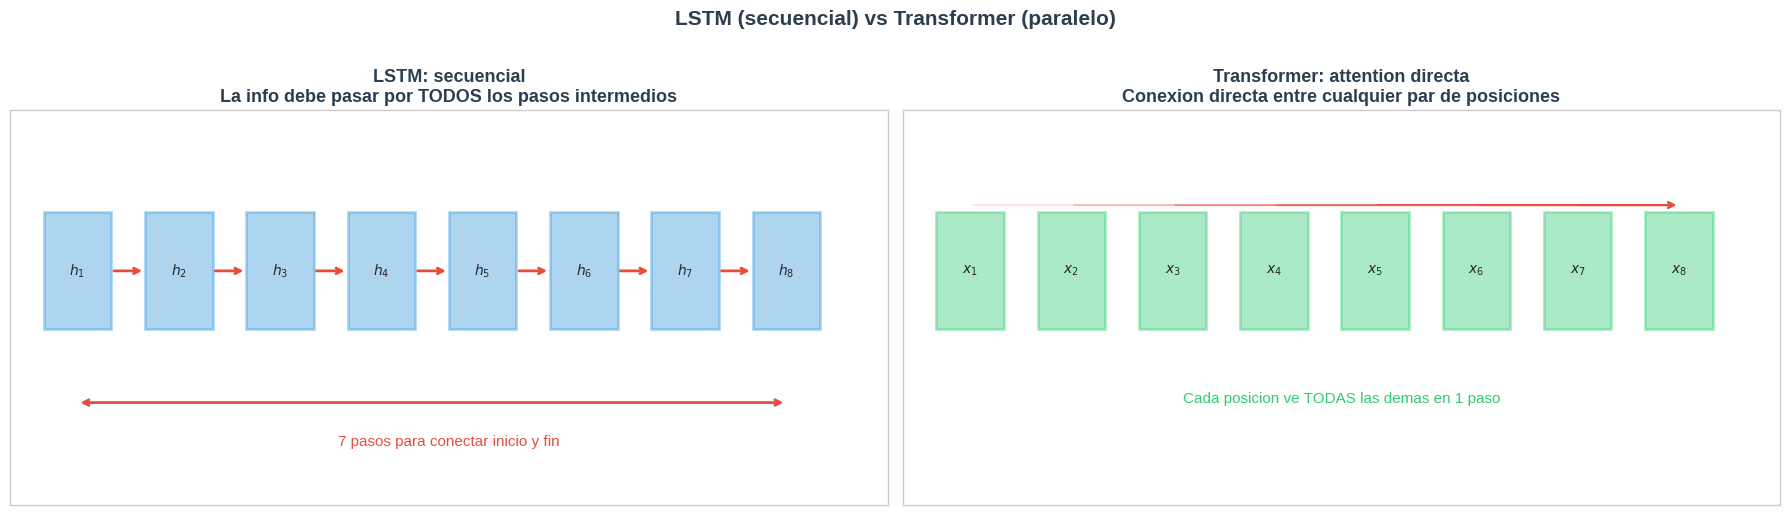

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'
C_PURPLE = '#9b59b6'

# === LSTM vs Transformer: flujo de informacion ===
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# LSTM: secuencial
ax = axes[0]
n = 8
for t in range(n):
    ax.add_patch(plt.Rectangle((t*1.5, 0), 1, 0.8, facecolor=C_PRIMARY, alpha=0.4, edgecolor=C_PRIMARY, lw=2))
    ax.text(t*1.5+0.5, 0.4, f'$h_{{{t+1}}}$', ha='center', va='center', fontsize=10)
    if t < n-1:
        ax.annotate('', xy=((t+1)*1.5, 0.4), xytext=(t*1.5+1, 0.4),
                    arrowprops=dict(arrowstyle='->', color=C_DANGER, lw=2))

# Marcar distancia
ax.annotate('', xy=(0.5, -0.5), xytext=((n-1)*1.5+0.5, -0.5),
            arrowprops=dict(arrowstyle='<->', color=C_DANGER, lw=2))
ax.text(n*1.5/2, -0.8, f'{n-1} pasos para conectar inicio y fin', ha='center', color=C_DANGER, fontsize=11)

ax.set_xlim(-0.5, n*1.5+0.5)
ax.set_ylim(-1.2, 1.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('LSTM: secuencial\nLa info debe pasar por TODOS los pasos intermedios', fontsize=13, fontweight='bold', color=C_DARK)

# Transformer: attention directa
ax = axes[1]
positions = np.array([(t*1.5+0.5, 0.4) for t in range(n)])
for t in range(n):
    ax.add_patch(plt.Rectangle((t*1.5, 0), 1, 0.8, facecolor=C_SUCCESS, alpha=0.4, edgecolor=C_SUCCESS, lw=2))
    ax.text(t*1.5+0.5, 0.4, f'$x_{{{t+1}}}$', ha='center', va='center', fontsize=10)

# Flechas de attention: posicion 8 atiende a todas
target = 7
for source in range(n):
    if source != target:
        alpha = 0.15 + 0.85 * (source / n)
        ax.annotate('', xy=(target*1.5+0.5, 0.85), xytext=(source*1.5+0.5, 0.85),
                    arrowprops=dict(arrowstyle='->', color=C_DANGER, lw=1.5, alpha=alpha))

ax.text(n*1.5/2, -0.5, 'Cada posicion ve TODAS las demas en 1 paso', ha='center', color=C_SUCCESS, fontsize=11)
ax.set_xlim(-0.5, n*1.5+0.5)
ax.set_ylim(-1.2, 1.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Transformer: attention directa\nConexion directa entre cualquier par de posiciones', fontsize=13, fontweight='bold', color=C_DARK)

plt.suptitle('LSTM (secuencial) vs Transformer (paralelo)', fontsize=15, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

## 3. Self-Attention: El Mecanismo Central

La idea es elegante: para cada palabra/posicion, calculamos **cuanto debe "prestar atencion"** a cada otra posicion.

### Query, Key, Value (Q, K, V)

Cada posicion produce tres vectores:
- **Query (Q):** "Que estoy buscando?" — lo que esta posicion necesita saber
- **Key (K):** "Que tengo para ofrecer?" — lo que esta posicion puede aportar
- **Value (V):** "Cual es mi contenido?" — la informacion real que se transfiere

Los tres se calculan con matrices de pesos (aprendidas con gradient descent):

$$Q = X \cdot W_Q, \quad K = X \cdot W_K, \quad V = X \cdot W_V$$

### La formula de Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

Paso a paso:
1. **$Q K^T$:** Producto punto entre cada query y cada key. Resultado: una matriz de "scores" que dice cuanto cada posicion se relaciona con cada otra.
2. **$/ \sqrt{d_k}$:** Escalar para evitar que los valores sean demasiado grandes (estabilidad numerica).
3. **softmax:** Convierte los scores en probabilidades (suman 1 por fila). Cada fila dice: "cuanto atencion presto a cada posicion".
4. **$\times V$:** Multiplica por los values. El resultado es una mezcla ponderada de la informacion de todas las posiciones.

### Intuicion

Imagina una reunion de equipo. Cada persona (posicion) tiene:
- Una **pregunta** (query): "Necesito saber sobre X"
- Una **etiqueta** (key): "Yo se sobre Y"
- **Informacion** (value): el contenido real que comparte

El attention score entre la persona A y la persona B es: "La pregunta de A coincide con lo que B sabe?" Si si, A presta mucha atencion a B.

In [2]:
# === Self-Attention paso a paso con numeros ===
np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

# Ejemplo: secuencia de 4 posiciones, embeddings de dimension 3
seq_length = 4
d_model = 3  # dimension del embedding
d_k = 2      # dimension de Q, K, V

# Embeddings de entrada (en NLP serian word embeddings, en series temporales serian features)
X = np.array([
    [1.0, 0.5, 0.2],   # Posicion 1
    [0.3, 0.8, 0.1],   # Posicion 2
    [0.7, 0.2, 0.9],   # Posicion 3
    [0.1, 0.6, 0.4],   # Posicion 4
])

# Matrices de pesos (aprendidas con gradient descent)
W_Q = np.random.randn(d_model, d_k) * 0.5
W_K = np.random.randn(d_model, d_k) * 0.5
W_V = np.random.randn(d_model, d_k) * 0.5

print("ENTRADA (X):")
print(f"  Shape: {X.shape} (4 posiciones x 3 features)")
print(f"  {X}")

print(f"\nPESOS (aprendidos con gradient descent):")
print(f"  W_Q: {W_Q.shape}, W_K: {W_K.shape}, W_V: {W_V.shape}")

# Paso 1: Calcular Q, K, V
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print(f"\nPaso 1: Q = X @ W_Q")
print(f"  Q = {Q}")
print(f"\n  K = X @ W_K")
print(f"  K = {K}")
print(f"\n  V = X @ W_V")
print(f"  V = {V}")

# Paso 2: Scores = Q @ K^T
scores = Q @ K.T
print(f"\nPaso 2: Scores = Q @ K^T")
print(f"  Scores = {scores}")
print(f"  Cada celda (i,j) dice: cuanto la posicion i atiende a la posicion j")

# Paso 3: Escalar
scores_scaled = scores / np.sqrt(d_k)
print(f"\nPaso 3: Escalar / sqrt(d_k={d_k})")
print(f"  Scores escalados = {scores_scaled}")

# Paso 4: Softmax
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

attention_weights = softmax(scores_scaled)
print(f"\nPaso 4: Softmax (cada fila suma 1)")
print(f"  Attention weights =")
print(f"  {attention_weights}")
print(f"  Suma por fila: {attention_weights.sum(axis=1)}")

# Paso 5: Output = weights @ V
output = attention_weights @ V
print(f"\nPaso 5: Output = Attention_weights @ V")
print(f"  Output = {output}")
print(f"  Cada fila es una mezcla ponderada de todos los Values")

ENTRADA (X):
  Shape: (4, 3) (4 posiciones x 3 features)
  [[1.  0.5 0.2]
 [0.3 0.8 0.1]
 [0.7 0.2 0.9]
 [0.1 0.6 0.4]]

PESOS (aprendidos con gradient descent):
  W_Q: (3, 2), W_K: (3, 2), W_V: (3, 2)

Paso 1: Q = X @ W_Q
  Q = [[ 0.387  0.288]
 [ 0.322  0.577]
 [ 0.133 -0.001]
 [ 0.172  0.403]]

  K = X @ W_K
  K = [[ 0.626  0.473]
 [ 0.026  0.309]
 [ 0.297  0.113]
 [-0.155  0.108]]

  V = X @ W_V
  V = [[-0.412 -1.066]
 [-0.704 -0.496]
 [-0.544 -0.584]
 [-0.708 -0.202]]

Paso 2: Scores = Q @ K^T
  Scores = [[ 0.378  0.099  0.148 -0.029]
 [ 0.474  0.186  0.161  0.013]
 [ 0.083  0.003  0.039 -0.021]
 [ 0.298  0.129  0.097  0.017]]
  Cada celda (i,j) dice: cuanto la posicion i atiende a la posicion j

Paso 3: Escalar / sqrt(d_k=2)
  Scores escalados = [[ 0.268  0.07   0.104 -0.02 ]
 [ 0.335  0.132  0.114  0.009]
 [ 0.058  0.002  0.028 -0.015]
 [ 0.211  0.091  0.069  0.012]]

Paso 4: Softmax (cada fila suma 1)
  Attention weights =
  [[0.292 0.24  0.248 0.219]
 [0.3   0.244 0.24  0.216]

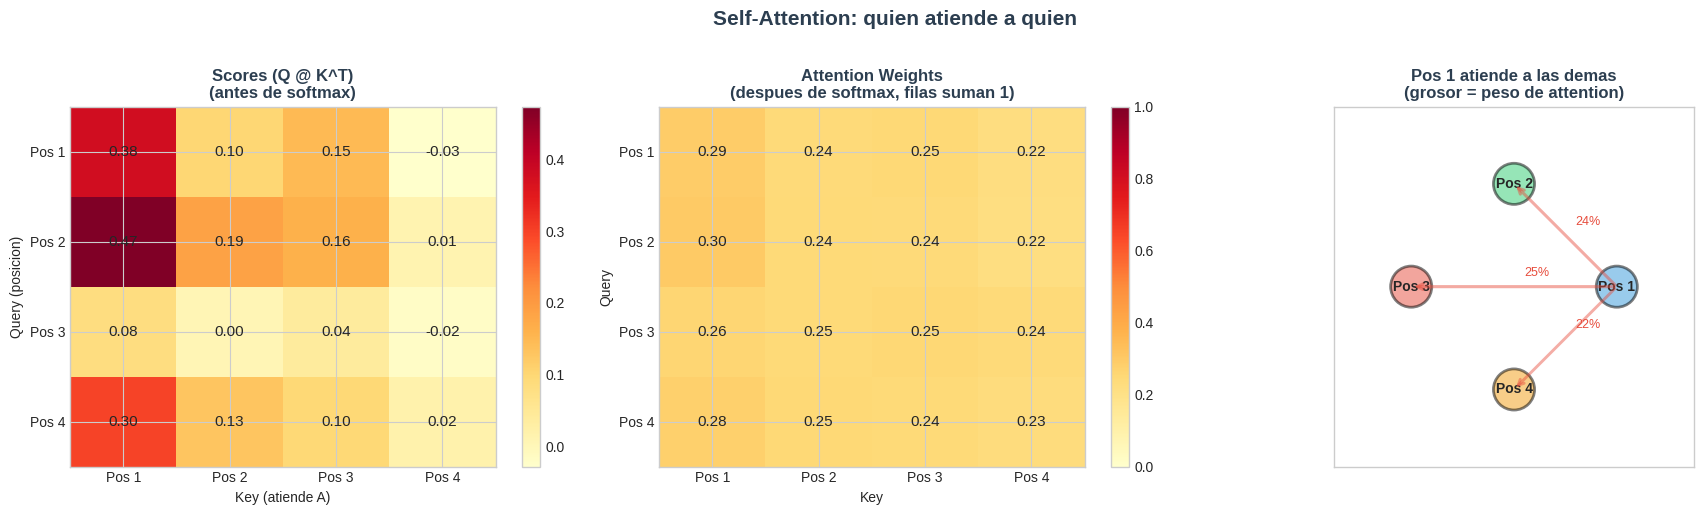

In [3]:
# === Visualizar la matriz de attention ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['Pos 1', 'Pos 2', 'Pos 3', 'Pos 4']

# Scores raw
ax = axes[0]
im = ax.imshow(scores, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{scores[i,j]:.2f}', ha='center', va='center', fontsize=11)
ax.set_title('Scores (Q @ K^T)\n(antes de softmax)', fontsize=12, fontweight='bold', color=C_DARK)
ax.set_xlabel('Key (atiende A)')
ax.set_ylabel('Query (posicion)')
plt.colorbar(im, ax=ax)

# Attention weights
ax = axes[1]
im = ax.imshow(attention_weights, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{attention_weights[i,j]:.2f}', ha='center', va='center', fontsize=11,
                fontweight='bold' if attention_weights[i,j] > 0.3 else 'normal')
ax.set_title('Attention Weights\n(despues de softmax, filas suman 1)', fontsize=12, fontweight='bold', color=C_DARK)
ax.set_xlabel('Key')
ax.set_ylabel('Query')
plt.colorbar(im, ax=ax)

# Grafo de attention para posicion 1
ax = axes[2]
angles = np.linspace(0, 2*np.pi, 5)[:-1]
pos_x = np.cos(angles) * 2
pos_y = np.sin(angles) * 2
colors_pos = [C_PRIMARY, C_SUCCESS, C_DANGER, C_ORANGE]

for i in range(4):
    circle = plt.Circle((pos_x[i], pos_y[i]), 0.4, color=colors_pos[i], alpha=0.5, ec='black', lw=2)
    ax.add_patch(circle)
    ax.text(pos_x[i], pos_y[i], f'Pos {i+1}', ha='center', va='center', fontsize=10, fontweight='bold')

# Flechas de attention desde posicion 1
query_pos = 0
for j in range(4):
    if j != query_pos:
        w = attention_weights[query_pos, j]
        ax.annotate('', xy=(pos_x[j], pos_y[j]),
                    xytext=(pos_x[query_pos], pos_y[query_pos]),
                    arrowprops=dict(arrowstyle='->', color=C_DANGER, lw=1+w*5, alpha=0.3+w*0.7))
        mid_x = (pos_x[query_pos] + pos_x[j]) / 2
        mid_y = (pos_y[query_pos] + pos_y[j]) / 2
        ax.text(mid_x+0.2, mid_y+0.2, f'{w:.0%}', fontsize=9, color=C_DANGER)

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'Pos 1 atiende a las demas\n(grosor = peso de attention)', fontsize=12, fontweight='bold', color=C_DARK)

plt.suptitle('Self-Attention: quien atiende a quien', fontsize=15, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

## 4. Multi-Head Attention: Mirar desde Multiples Angulos

Un solo attention head captura UN tipo de relacion. Pero las relaciones son multiples:
- En texto: relacion gramatical, semantica, posicional...
- En sensores: relacion entre temperatura y presion, entre vibracion y RPM...

**Multi-Head Attention** ejecuta **h** attention heads en paralelo, cada uno con sus propios $W_Q, W_K, W_V$:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$$

Donde cada $\text{head}_i = \text{Attention}(X W_Q^i, X W_K^i, X W_V^i)$

- GPT-3: 96 heads
- BERT: 12 heads
- Un transformer pequeno: 4-8 heads

Cada head aprende a "mirar" algo diferente. Uno puede capturar relaciones locales (ciclo actual vs anterior), otro relaciones globales (patron de degradacion a largo plazo).

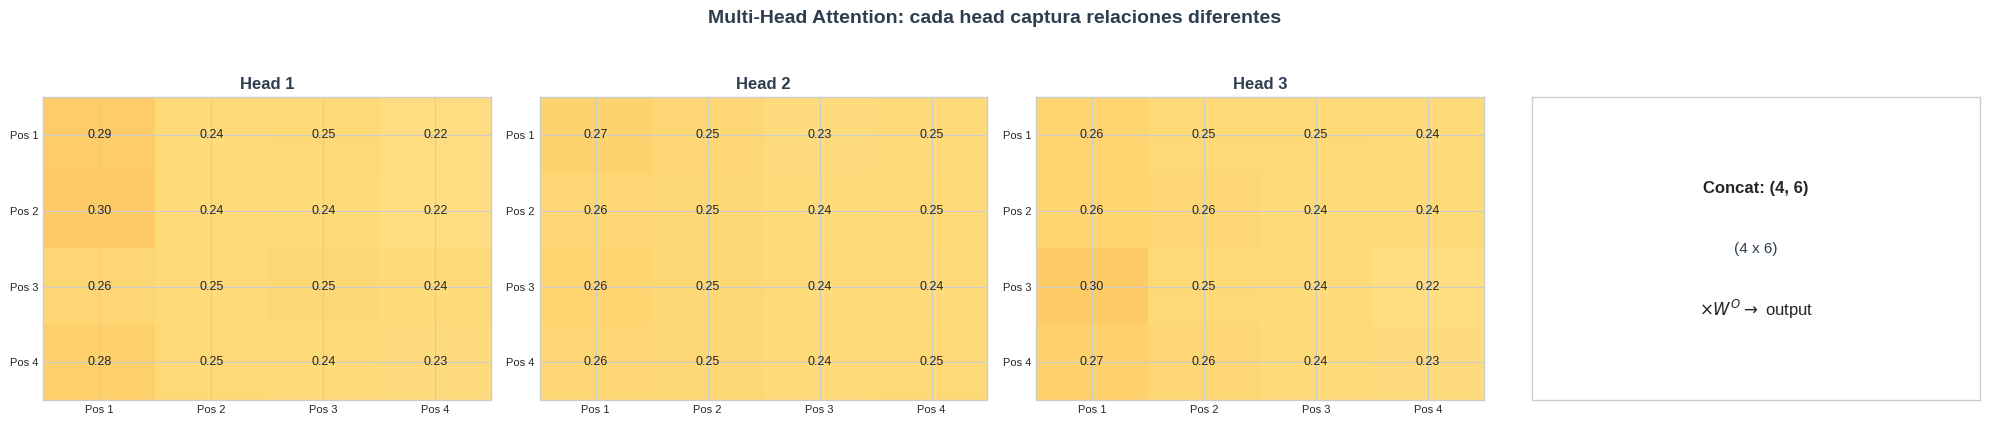

Observa como cada head tiene patrones de attention DIFERENTES.
Head 1 puede capturar relaciones locales, Head 2 globales, Head 3 especificas.


In [4]:
# === Multi-Head Attention simplificado ===
n_heads = 3
d_head = 2

fig, axes = plt.subplots(1, n_heads + 1, figsize=(20, 4))

all_outputs = []

for h in range(n_heads):
    np.random.seed(h * 10 + 42)
    W_Q_h = np.random.randn(d_model, d_head) * 0.5
    W_K_h = np.random.randn(d_model, d_head) * 0.5
    W_V_h = np.random.randn(d_model, d_head) * 0.5
    
    Q_h = X @ W_Q_h
    K_h = X @ W_K_h
    V_h = X @ W_V_h
    
    scores_h = Q_h @ K_h.T / np.sqrt(d_head)
    weights_h = softmax(scores_h)
    output_h = weights_h @ V_h
    all_outputs.append(output_h)
    
    ax = axes[h]
    im = ax.imshow(weights_h, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{weights_h[i,j]:.2f}', ha='center', va='center', fontsize=9)
    ax.set_title(f'Head {h+1}', fontsize=12, fontweight='bold', color=C_DARK)

# Concatenar outputs
concat_output = np.concatenate(all_outputs, axis=-1)
ax = axes[n_heads]
ax.text(0.5, 0.7, f'Concat: {concat_output.shape}', ha='center', va='center', fontsize=12, fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5, 0.5, f'({seq_length} x {n_heads * d_head})', ha='center', va='center', fontsize=11,
        transform=ax.transAxes, color=C_DARK)
ax.text(0.5, 0.3, r'$\times W^O \rightarrow$ output', ha='center', va='center', fontsize=12,
        transform=ax.transAxes)
ax.set_xticks([])
ax.set_yticks([])

plt.suptitle('Multi-Head Attention: cada head captura relaciones diferentes',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.05)
plt.tight_layout()
plt.show()

print("Observa como cada head tiene patrones de attention DIFERENTES.")
print("Head 1 puede capturar relaciones locales, Head 2 globales, Head 3 especificas.")

## 5. Positional Encoding: Donde Estoy?

**Problema:** El self-attention trata todas las posiciones IGUAL. No sabe si $x_1$ viene antes o despues de $x_5$. Para una LSTM esto no es problema porque procesa en orden, pero el Transformer ve todo de golpe.

**Solucion:** Sumar a cada embedding un vector que codifica su posicion:

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

Cada posicion tiene un patron unico de senos y cosenos. El modelo puede aprender relaciones posicionales a partir de estos patrones.

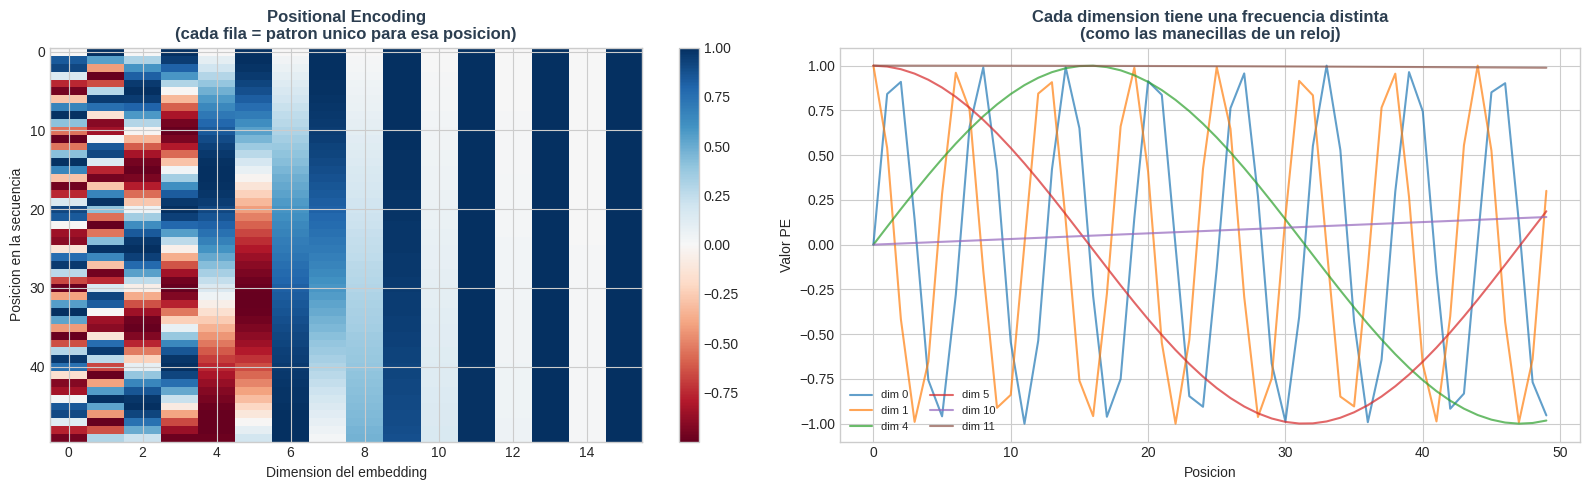

Dimensiones bajas = frecuencias altas (cambian rapido)
Dimensiones altas = frecuencias bajas (cambian lento)
Como un reloj: segundos cambian rapido, horas cambian lento
Juntas, codifican una posicion unica.


In [5]:
# === Positional Encoding ===
def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:, np.newaxis]
    div_term = 10000 ** (2 * np.arange(d_model // 2)[np.newaxis, :] / d_model)
    PE[:, 0::2] = np.sin(position / div_term)
    PE[:, 1::2] = np.cos(position / div_term)
    return PE

pe = positional_encoding(50, 16)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
ax = axes[0]
im = ax.imshow(pe, cmap='RdBu', aspect='auto')
ax.set_xlabel('Dimension del embedding')
ax.set_ylabel('Posicion en la secuencia')
ax.set_title('Positional Encoding\n(cada fila = patron unico para esa posicion)', fontsize=12, fontweight='bold', color=C_DARK)
plt.colorbar(im, ax=ax)

# Curvas para dimensiones seleccionadas
ax = axes[1]
for d in [0, 1, 4, 5, 10, 11]:
    ax.plot(range(50), pe[:, d], linewidth=1.5, label=f'dim {d}', alpha=0.7)
ax.set_xlabel('Posicion')
ax.set_ylabel('Valor PE')
ax.set_title('Cada dimension tiene una frecuencia distinta\n(como las manecillas de un reloj)', fontsize=12, fontweight='bold', color=C_DARK)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

print("Dimensiones bajas = frecuencias altas (cambian rapido)")
print("Dimensiones altas = frecuencias bajas (cambian lento)")
print("Como un reloj: segundos cambian rapido, horas cambian lento")
print("Juntas, codifican una posicion unica.")

## 6. Arquitectura Completa del Transformer

### Encoder (para entender la entrada)
```
Input Embedding + Positional Encoding
            |
    [Multi-Head Attention]  <- "cada posicion mira a todas"
            |
    [Add & Norm]            <- conexion residual + layer norm
            |
    [Feed Forward]          <- red neuronal clasica (2 capas Dense)
            |
    [Add & Norm]            <- otra conexion residual
            |
     x N capas              <- repetir N veces (GPT-3: N=96)
```

### Decoder (para generar la salida)
Igual que el encoder pero con **Masked Attention**: cada posicion solo puede ver las posiciones ANTERIORES (no puede hacer "trampa" mirando el futuro).

### Componentes clave que NO son attention

| Componente | Que hace | Por que |
|---|---|---|
| **Residual Connection** | $\text{output} = x + \text{sublayer}(x)$ | Permite gradientes fluir sin degradarse (como el cell state de LSTM) |
| **Layer Normalization** | Normaliza activaciones por capa | Estabiliza entrenamiento |
| **Feed Forward** | 2 capas Dense con ReLU | Agrega no-linealidad y capacidad |
| **Dropout** | Apaga neuronas al azar | Regularizacion |

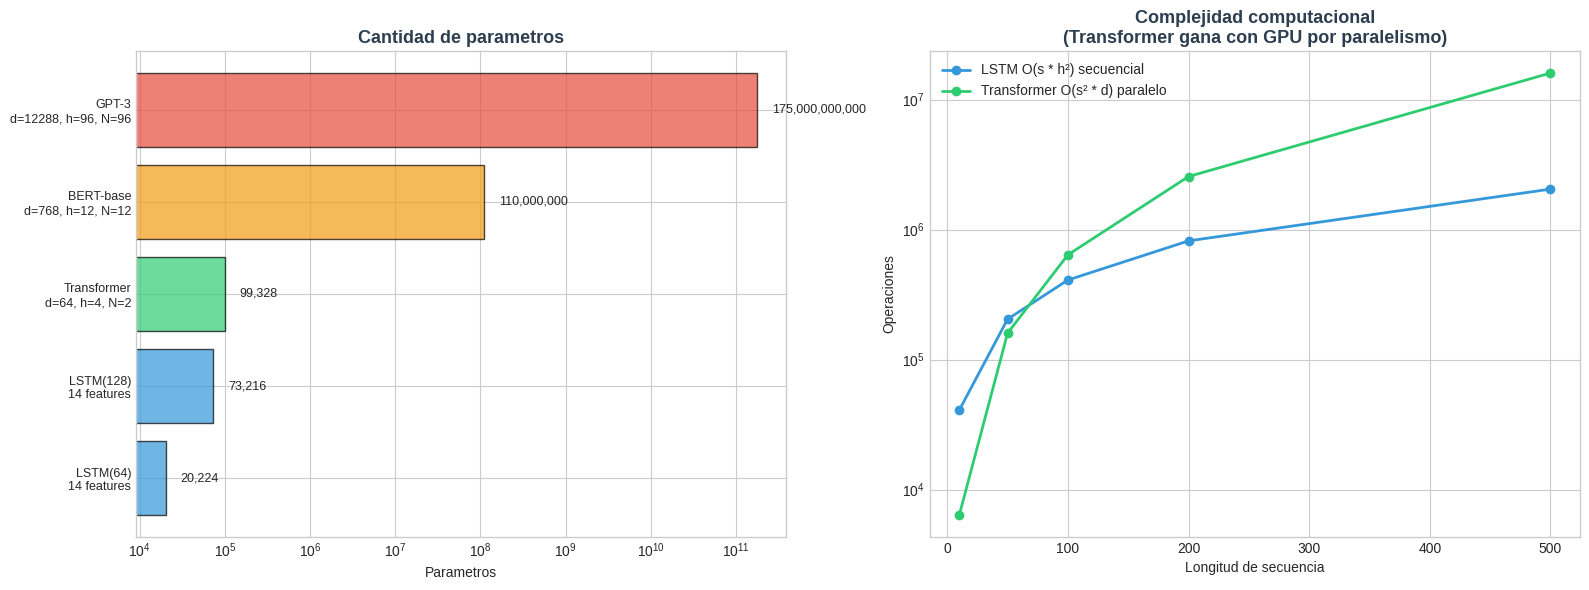

LSTM: menos operaciones pero SECUENCIALES (no se puede paralelizar)
Transformer: mas operaciones pero PARALELAS (GPU las ejecuta todas a la vez)
Por eso Transformer es mas rapido en GPU a pesar de tener mas operaciones.


In [6]:
# === Comparacion de parametros y velocidad ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Parametros
models_data = {
    'LSTM(64)\n14 features': 4 * 64 * (64 + 14) + 4 * 64,
    'LSTM(128)\n14 features': 4 * 128 * (128 + 14) + 4 * 128,
    'Transformer\nd=64, h=4, N=2': 2 * (3*64*64 + 64*64 + 2*64*256 + 64) + 14*64,
    'BERT-base\nd=768, h=12, N=12': 110_000_000,
    'GPT-3\nd=12288, h=96, N=96': 175_000_000_000,
}

ax = axes[0]
names = list(models_data.keys())
params = list(models_data.values())
colors = [C_PRIMARY, C_PRIMARY, C_SUCCESS, C_ORANGE, C_DANGER]
bars = ax.barh(range(len(names)), params, color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Parametros')
ax.set_title('Cantidad de parametros', fontsize=13, fontweight='bold', color=C_DARK)
for bar, val in zip(bars, params):
    ax.text(val * 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)

# LSTM vs Transformer: secuencial vs paralelo
ax = axes[1]
seq_lengths = [10, 50, 100, 200, 500]

# LSTM: O(seq_len * hidden^2) secuencial
lstm_ops = [s * 64**2 for s in seq_lengths]
# Transformer: O(seq_len^2 * d_model) paralelo
trans_ops = [s**2 * 64 for s in seq_lengths]

ax.plot(seq_lengths, lstm_ops, 'o-', color=C_PRIMARY, linewidth=2, label='LSTM O(s * h²) secuencial')
ax.plot(seq_lengths, trans_ops, 'o-', color=C_SUCCESS, linewidth=2, label=r'Transformer O(s² * d) paralelo')
ax.set_xlabel('Longitud de secuencia')
ax.set_ylabel('Operaciones')
ax.set_title('Complejidad computacional\n(Transformer gana con GPU por paralelismo)', fontsize=13, fontweight='bold', color=C_DARK)
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("LSTM: menos operaciones pero SECUENCIALES (no se puede paralelizar)")
print("Transformer: mas operaciones pero PARALELAS (GPU las ejecuta todas a la vez)")
print("Por eso Transformer es mas rapido en GPU a pesar de tener mas operaciones.")

## 7. Tabla Comparativa: LSTM vs Transformer

| Aspecto | LSTM | Transformer |
|---|---|---|
| **Mecanismo** | Puertas + cell state (recurrencia) | Self-attention (sin recurrencia) |
| **Procesamiento** | Secuencial (paso a paso) | Paralelo (todo a la vez) |
| **Distancia** | Se degrada con la distancia | Conexion directa entre cualquier par |
| **Paralelismo GPU** | Limitado | Total |
| **Positional info** | Implicita (procesa en orden) | Explicita (positional encoding) |
| **Memoria** | $h_t$ + $C_t$ (fija) | Attention weights (dinamica, crece con $s^2$) |
| **Datos necesarios** | Funciona con pocos datos | Necesita MUCHOS datos |
| **Interpretabilidad** | Dificil de interpretar | Attention weights son interpretables |
| **Mejor para** | Series cortas, pocos datos | Secuencias largas, mucho dato, GPU |

### Cuando usar cada uno

- **LSTM:** Tu proyecto C-MAPSS (100 motores, secuencias de 30 pasos, 14 features). Datos limitados.
- **Transformer:** NLP (GPT, BERT), vision (ViT), audio, series temporales con miles de muestras.

### La evolucion

```
RNN (1986)
 |
 v
LSTM (1997) <- resuelve vanishing gradient con cell state
 |
 v
Attention + LSTM (2014-2016) <- "attention como complemento"
 |
 v
Transformer (2017) <- "attention es TODO lo que necesitas"
 |
 v
GPT, BERT, ViT, etc. (2018+) <- domina NLP, vision, audio...
```

## 8. Por que GPT Funciona: Transformer como Motor de Lenguaje

GPT (Generative Pre-trained Transformer) es un Transformer **decoder-only** entrenado para predecir la siguiente palabra:

```
Entrada:  "El gato se sento en el ___"
Target:   "sofa"
```

Entrenado con TODO internet (~300B tokens para GPT-3):
1. Masked self-attention: cada posicion solo ve las anteriores
2. Predice la siguiente palabra, calcula cross-entropy loss
3. Gradient descent ajusta los 175B parametros

**Los "175 mil millones de parametros" de GPT-3 son exactamente lo mismo conceptualmente que los 20,000 de tu LSTM:** pesos en matrices que se optimizan con gradient descent para minimizar una loss function. La diferencia es solo de escala y arquitectura.

### Por que funciona para "razonar"

GPT no "razona". Lo que hace es:
1. Attention le permite ver TODA la secuencia de entrada
2. Los patrones estadisticos de lenguaje humano codifican logica, causalidad, conocimiento
3. Con 175B parametros y todo internet, memoriza suficientes patrones para PARECER que razona

Es pattern matching a una escala sin precedentes, no inteligencia general.

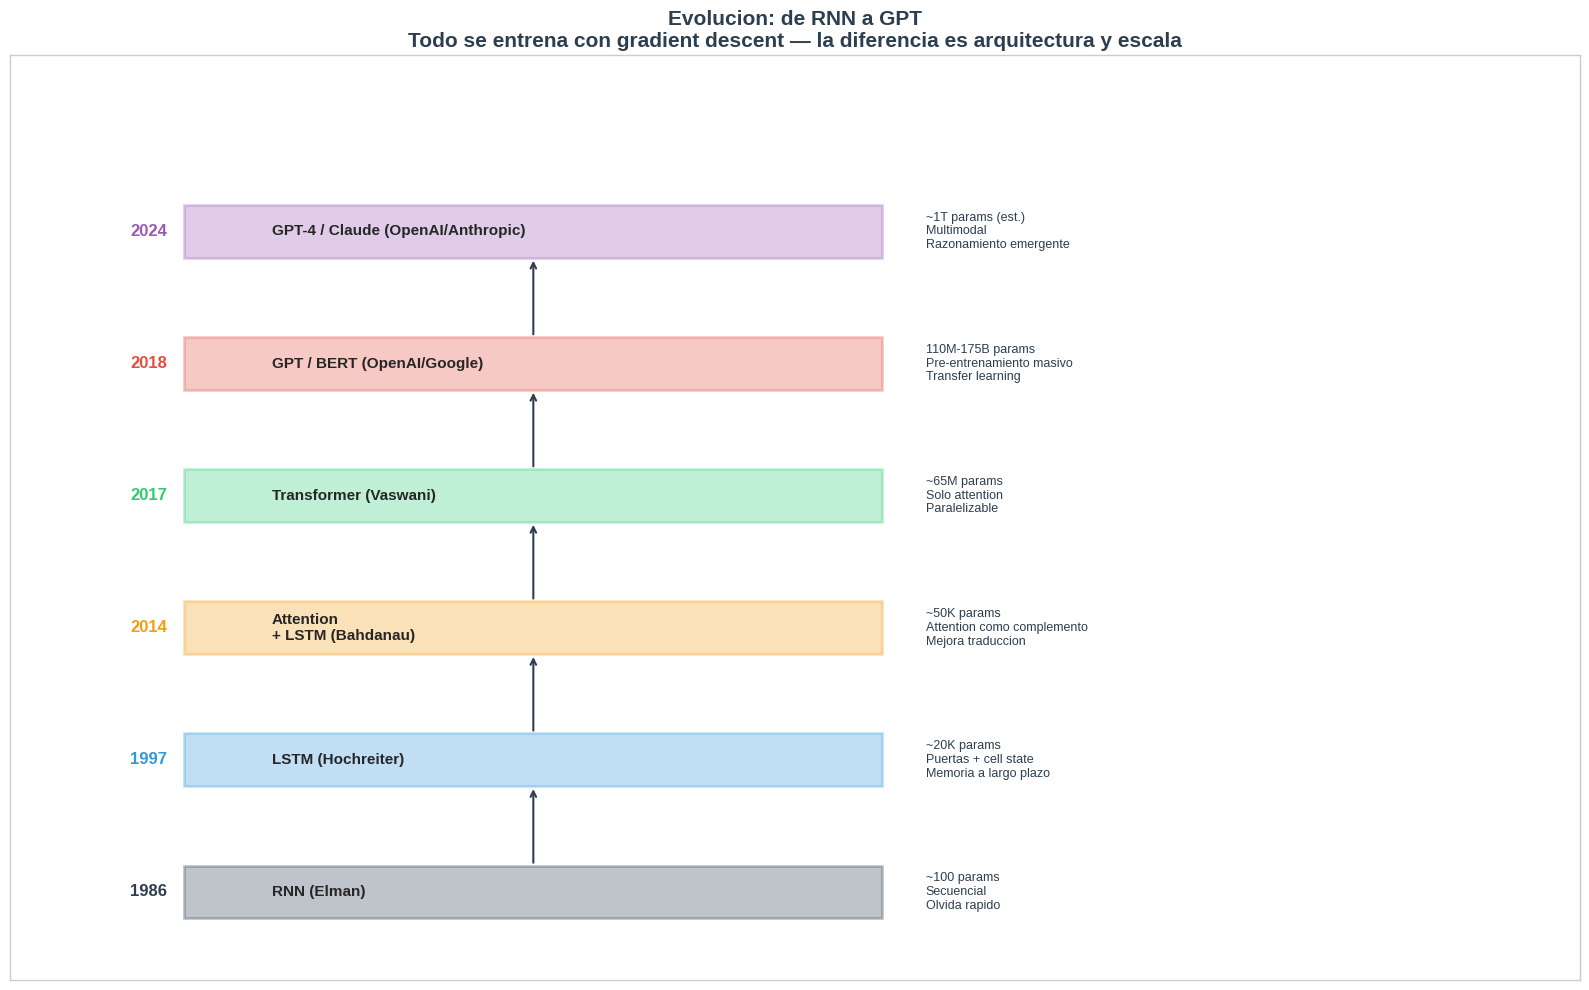

In [7]:
# === Resumen visual: la familia completa ===
fig, ax = plt.subplots(figsize=(16, 10))

timeline = [
    (1986, 'RNN', 'Elman', '~100 params\nSecuencial\nOlvida rapido', C_DARK),
    (1997, 'LSTM', 'Hochreiter', '~20K params\nPuertas + cell state\nMemoria a largo plazo', C_PRIMARY),
    (2014, 'Attention\n+ LSTM', 'Bahdanau', '~50K params\nAttention como complemento\nMejora traduccion', C_ORANGE),
    (2017, 'Transformer', 'Vaswani', '~65M params\nSolo attention\nParalelizable', C_SUCCESS),
    (2018, 'GPT / BERT', 'OpenAI/Google', '110M-175B params\nPre-entrenamiento masivo\nTransfer learning', C_DANGER),
    (2024, 'GPT-4 / Claude', 'OpenAI/Anthropic', '~1T params (est.)\nMultimodal\nRazonamiento emergente', C_PURPLE),
]

for i, (year, name, author, desc, color) in enumerate(timeline):
    y = i * 1.5
    rect = plt.Rectangle((2, y - 0.3), 8, 0.6, facecolor=color, alpha=0.3, edgecolor=color, lw=2)
    ax.add_patch(rect)
    ax.text(1.8, y, str(year), ha='right', va='center', fontsize=12, fontweight='bold', color=color)
    ax.text(3, y, f'{name} ({author})', ha='left', va='center', fontsize=11, fontweight='bold')
    ax.text(10.5, y, desc, ha='left', va='center', fontsize=9, color=C_DARK)
    
    if i > 0:
        ax.annotate('', xy=(6, y - 0.3), xytext=(6, (i-1)*1.5 + 0.3),
                    arrowprops=dict(arrowstyle='->', color=C_DARK, lw=1.5))

ax.set_xlim(0, 18)
ax.set_ylim(-1, len(timeline) * 1.5 + 0.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Evolucion: de RNN a GPT\nTodo se entrena con gradient descent — la diferencia es arquitectura y escala',
             fontsize=15, fontweight='bold', color=C_DARK)
plt.tight_layout()
plt.show()

## 9. Resumen

### Self-Attention en una frase
Cada posicion calcula cuanto debe "prestar atencion" a cada otra posicion usando productos punto entre queries y keys, y luego combina los values ponderados.

### La formula clave
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

### Por que reemplazo a las LSTM
1. **Paralelismo:** No es secuencial, usa toda la GPU
2. **Distancia:** Conexion directa entre cualquier par de posiciones
3. **Escalabilidad:** Funciona con billones de parametros
4. **Versatilidad:** Mismo mecanismo sirve para texto, imagen, audio, series temporales

### Lo que no cambia
Tanto LSTM como Transformer son, en el fondo, **matrices de pesos optimizadas con gradient descent**. La innovacion del Transformer no es matematica nueva — es una organizacion mas eficiente de las mismas operaciones basicas (multiplicaciones matriciales + activaciones no lineales).